## Cell 1 – Required packages

In [1]:
# =============================================================================
# Install required packages (only needed once)
# The user can instead create a new conda environment with all required packages 
# =============================================================================
from scipy.optimize import curve_fit
import subprocess
import cobra
subprocess.run(['pip', 'install', 'cobra', 'openpyxl', 'scipy', 'matplotlib', 'numpy', 'pandas'], check=True)
print('All packages installed!')

All packages installed!


## Cell 2 – Load the metabolic model

We load the SBML model using COBRApy.

In [2]:
# =============================================================================
# CHANGE THIS PATH to your model file 
# =============================================================================
MODEL_FILE = 'iMS837_modified.xml'

model = cobra.io.read_sbml_model(MODEL_FILE)

print(f'Model ID: {model.id}')
print(f'Reactions: {len(model.reactions)}')
print(f'Metabolites: {len(model.metabolites)}')
print(f'Genes: {len(model.genes)}')

# Confirm the biomass (objective) reaction
print('\nObjective function:')
print(' ', model.objective.to_json())

Model ID: iMS837
Reactions: 891
Metabolites: 802
Genes: 837

Objective function:
  {'name': 'b966093e-a6d1-11f1-82ca-6a67f7556f11', 'expression': {'type': 'Add', 'args': [{'type': 'Mul', 'args': [{'type': 'Number', 'value': 1.0}, {'type': 'Symbol', 'name': 'BOF'}]}, {'type': 'Mul', 'args': [{'type': 'Number', 'value': -1.0}, {'type': 'Symbol', 'name': 'BOF_reverse_2629d'}]}]}, 'direction': 'max'}


## Cell 3 – Inspect key reactions

We check the reactions we'll be modifying:  
BHAC reactions, RubiscO reactions (R_RBPC, R_RBCh), and key exchanges (CO₂, NH₄, HCO₃, light).

In [3]:
# =============================================================================
# Auto-detect all reaction IDs from the loaded model.
# =============================================================================

# Photon reactions (auto-detected) 
PHOTON_REACTIONS = sorted([r.id for r in model.reactions if 'photon' in r.id.lower()])
print(f'Found {len(PHOTON_REACTIONS)} photon reactions:')
for p in PHOTON_REACTIONS:
    print(f'  {p}')

# BHAC reactions (reactions belong to New Pathway)
# Search for reactions containing BHCC, BHCB, BHCD, BHCA
BHAC_REACTIONS = []
for suffix in ['BHCC', 'BHCB', 'BHCD', 'BHCA']:
    match = next((r.id for r in model.reactions if suffix in r.id), None)
    if match:
        BHAC_REACTIONS.append(match)
print(f'\nBHAC reactions found: {BHAC_REACTIONS}')

# Rubisco reactions 
RUBISCO_RBCh = next((r.id for r in model.reactions if 'RBCh' in r.id), None)
RUBISCO_RBPC = next((r.id for r in model.reactions if 'RBPC' in r.id), None)
print(f'RBCh  → {RUBISCO_RBCh}')
print(f'RBPC  → {RUBISCO_RBPC}')

# Biomass reaction
BIOMASS_RXN = next((r.id for r in model.reactions if 'BOF' in r.id or 'biomass' in r.id.lower()), None)
print(f'Biomass → {BIOMASS_RXN}')

# Exchange reactions
EX_CO2  = next((r.id for r in model.reactions if 'EX' in r.id and 'co2'  in r.id.lower()), None)
EX_HCO3 = next((r.id for r in model.reactions if 'EX' in r.id and 'hco3' in r.id.lower()), None)
EX_NH4  = next((r.id for r in model.reactions if 'EX' in r.id and 'nh4'  in r.id.lower()), None)
EX_FE3  = next((r.id for r in model.reactions if 'EX' in r.id and 'fe3'  in r.id.lower()), None)
print(f'\nExchange reactions detected:')
print(f'  CO2  → {EX_CO2}')
print(f'  HCO3 → {EX_HCO3}')
print(f'  NH4  → {EX_NH4}')
print(f'  Fe3  → {EX_FE3}')

# Double check 
missing = [name for name, val in [('RUBISCO_RBCh', RUBISCO_RBCh), ('RUBISCO_RBPC', RUBISCO_RBPC),
           ('BIOMASS_RXN', BIOMASS_RXN), ('EX_CO2', EX_CO2), ('EX_HCO3', EX_HCO3),
           ('EX_NH4', EX_NH4), ('EX_FE3', EX_FE3)] if val is None]
if missing:
    print(f'\n⚠️  Could not find: {missing}  — check reaction IDs manually!')
else:
    print('\n✅ All key reactions found.')

print('\n--- BHAC reactions ---')
for rid in BHAC_REACTIONS:
    r = model.reactions.get_by_id(rid)
    #print(f'  {rid}: lb={1}, ub={r.upper_bound}')
    print(f'  {rid}: lb={r.lower_bound}, ub={r.upper_bound}')

print('\n--- Rubisco-related reactions ---')
for rid in [RUBISCO_RBCh, RUBISCO_RBPC]:
    r = model.reactions.get_by_id(rid)
    print(f'  {rid}: lb={r.lower_bound}, ub={r.upper_bound}')
    print(f'         {r.reaction}')

print('\n--- Key exchange reactions (default bounds) ---')
for rid in [EX_CO2, EX_HCO3, EX_NH4, EX_FE3]:
    r = model.reactions.get_by_id(rid)
    print(f'  {rid}: lb={r.lower_bound}, ub={r.upper_bound}')

Found 15 photon reactions:
  EX_photon410_e
  EX_photon430_e
  EX_photon450_e
  EX_photon470_e
  EX_photon490_e
  EX_photon510_e
  EX_photon530_e
  EX_photon550_e
  EX_photon570_e
  EX_photon590_e
  EX_photon610_e
  EX_photon630_e
  EX_photon650_e
  EX_photon670_e
  EX_photon690_e

BHAC reactions found: ['BHCC', 'BHCB', 'BHCD', 'BHCA']
RBCh  → RBCh
RBPC  → RBPC
Biomass → BOF

Exchange reactions detected:
  CO2  → EX_co2_e
  HCO3 → EX_hco3_e
  NH4  → EX_nh4_e
  Fe3  → EX_fe3_e

✅ All key reactions found.

--- BHAC reactions ---
  BHCC: lb=0.0, ub=1000.0
  BHCB: lb=0.0, ub=1000.0
  BHCD: lb=0.0, ub=1000.0
  BHCA: lb=0.0, ub=1000.0

--- Rubisco-related reactions ---
  RBCh: lb=0.0, ub=1000.0
         o2_c + rb15bp_c --> 2pglyc_c + 3pg_c + 2.0 h_c
  RBPC: lb=0.0, ub=1000.0
         co2_c + h2o_c + rb15bp_c --> 2.0 3pg_c + 2.0 h_c

--- Key exchange reactions (default bounds) ---
  EX_co2_e: lb=-1000.0, ub=1000.0
  EX_hco3_e: lb=-1000.0, ub=1000.0
  EX_nh4_e: lb=-1000.0, ub=1000.0
  EX_fe3_e

## Cell 4 – Set medium conditions (BG11)


In [4]:
# =============================================================================
# CHANGE THIS PATH to your medium file
# =============================================================================
import pandas as pd
bg11 = pd.read_csv("BG11.csv", sep=";")
bg11

,Compound,BiGG,ModelSeed,KEGG
0,Sodium,na1,cpd00971,C01330
1,Nitrate,no3,cpd00209,C00244
2,Magnesium,mg2,cpd00254,C00305
3,EDTA,NaN,NaN,NaN
4,Ferric iron,fe3,cpd10516,C14819
5,Ammonium,nh4,cpd00013,C01342
6,Calcium,ca2,cpd00063,C00076
7,Chloride,cl,cpd00099,C00698
8,Citrate,cit,cpd00137,C00158
9,Sulfate,so4,cpd00048,C00059


## Cell 5 – Set further experimental modifications into the medium

According to the experimental setup:
- **NH₄ closed** → `R_EX_nh4_e` lower bound = 0 (no uptake)
- **HCO₃ closed** → `R_EX_hco3_e` lower bound = 0 (no uptake)
- **Iron low** → `R_EX_fe3_e` lower bound = −0.01 (very limited)
- **Light at 100 µE m⁻² s⁻¹** → photon exchanges set to −300 mmol/gDW/h (adjust if needed)
- **CO₂** → set per condition in the next cell

**⚠️ Important:** Negative flux = *uptake* (the organism takes it in). Positive = secretion.

This function returns a modified **copy** of the model — the original is never changed.

In [5]:
# =============================================================================
# We can adopt these values#

# Light: total photon flux (mmol photons / gDW / h) which distributed equally over all wavelength bands. 
# It is considered to be negative as it is a uptake by the cell. 
# 100 µE m⁻² s⁻¹ is considered 300 mmol photons/gDW/h in our analysis.
# There is no universal conversion because it depends on cell size, dry weight per cell, and the effective light-absorbing area.
# =============================================================================

TOTAL_PHOTON_FLUX = -300.0     # adjust if growth is unrealistically high or zero
photon_per_band   = TOTAL_PHOTON_FLUX / len(PHOTON_REACTIONS)

# Iron: small but non-zero (The medium has 0.006 g/L ferric ammonium citrate)
IRON_UPTAKE = -0.01            # mmol/gDW/h

# CO2 uptake limits for each condition (negative = uptake)
# These are proportional to CO₂ partial pressure.
# It is started with these values and can be adjusted if FBA growth deviates a lot from the experiment.
CO2_UPTAKE = {
    '1% CO2': -1.99,
    '0.5% CO2': -0.995,
    '0.3% CO2': -0.597,
}


def setup_medium(base_model, co2_condition, bg11_df, factor=1.0, verbose=True):
    """
    Returns a copy of the model with BG11 medium conditions applied:
    - NH4 closed
    - HCO3 closed
    - Iron low
    - Light on (all photon wavelength bands)
    - CO2 uptake set to the specified condition
    """
    m = base_model.copy()
    ex_ids = {ex.id for ex in m.exchanges}

    # --- close all exchanges ---
    for ex in m.exchanges:
        ex.lower_bound = 0.0

    # --- bulk solutes: unlimited ---
    unlimited = {"EX_h2o_e", "EX_o2_e", "EX_h_e"}
    for ex_id in unlimited:
        if ex_id in ex_ids:
            m.reactions.get_by_id(ex_id).lower_bound = -1000.0 * factor

    # --- BG11 minerals ---
    for _, row in bg11_df.iterrows():
        bigg = str(row["BiGG"])
        if bigg == "nan":
            continue
        ex_id = f"EX_{bigg}_e"
        if ex_id not in ex_ids:
            continue
        ex = m.reactions.get_by_id(ex_id)
        # iron: small bound as in the original model
        if bigg in ("fe2", "fe3"):
            ex.lower_bound = IRON_UPTAKE * factor
        # bulk solutes already set above
        elif bigg in ("nh4", "hco3"):
            ex.lower_bound = 0.0  # no ammonium in BG11
        elif ex_id in unlimited:
            pass
        else:
            ex.lower_bound = -10.0 * factor


    if verbose:
        print("Active uptake reactions after applying BG11:")
        for ex in sorted(m.exchanges, key=lambda x: x.id):
            if ex.lower_bound < 0:
                print(f"  {ex.id:30s}  lb = {ex.lower_bound}")
    

    # Close NH4 and HCO3
    m.reactions.get_by_id(EX_NH4).lower_bound  = 0
    m.reactions.get_by_id(EX_HCO3).lower_bound = 0

    # Iron: low
    m.reactions.get_by_id(EX_FE3).lower_bound  = IRON_UPTAKE * factor

    # Light: distribute evenly across all photon wavelengths
    for phot_rxn in PHOTON_REACTIONS:
        try:
            m.reactions.get_by_id(phot_rxn).lower_bound = photon_per_band
        except:
            pass  # skip if wavelength not in model

    # CO2: set uptake limit
    m.reactions.get_by_id(EX_CO2).lower_bound = CO2_UPTAKE[co2_condition]

    return m

# Quick test
test_model = setup_medium(model, '1% CO2', bg11)
print('Medium setup test (1% CO2):')
print(f"  NH4  exchange lb: {test_model.reactions.get_by_id(EX_NH4).lower_bound}")
print(f"  HCO3 exchange lb: {test_model.reactions.get_by_id(EX_HCO3).lower_bound}")
print(f"  Fe3  exchange lb: {test_model.reactions.get_by_id(EX_FE3).lower_bound}")
print(f"  CO2  exchange lb: {test_model.reactions.get_by_id(EX_CO2).lower_bound}")
print(f"  Photon (first band) lb: {test_model.reactions.get_by_id(PHOTON_REACTIONS[0]).lower_bound:.3f}")

Active uptake reactions after applying BG11:
  EX_ca2_e                        lb = -10.0
  EX_cl_e                         lb = -10.0
  EX_co2_e                        lb = -10.0
  EX_cobalt2_e                    lb = -10.0
  EX_cu2_e                        lb = -10.0
  EX_fe3_e                        lb = -0.01
  EX_h2o_e                        lb = -1000.0
  EX_h_e                          lb = -1000.0
  EX_k_e                          lb = -10.0
  EX_mg2_e                        lb = -10.0
  EX_mn2_e                        lb = -10.0
  EX_mobd_e                       lb = -10.0
  EX_na1_e                        lb = -10.0
  EX_no3_e                        lb = -10.0
  EX_o2_e                         lb = -1000.0
  EX_pi_e                         lb = -10.0
  EX_so4_e                        lb = -10.0
  EX_zn2_e                        lb = -10.0
Medium setup test (1% CO2):
  NH4  exchange lb: 0
  HCO3 exchange lb: 0
  Fe3  exchange lb: -0.01
  CO2  exchange lb: -1.99
  Photon (first

## Cell 6 – Define FBA function for each strain and condition


In [6]:
# =============================================================================
# We define a function `run_fba()` that:
# 1. Takes the medium-configured model
# 2. Applies strain-specific modifications (block BHAC or not)
# 3. Adds the constraint `flux(R_RBPC) = 3 × flux(R_RBCh)`
# 4. Runs FBA and returns μ_FBA

# The R_RBPC = 3 × R_RBCh constraint** is added via COBRApy's `add_cons_vars()` — this is a linear constraint.
# =============================================================================

def run_fba(base_model, co2_condition, strain):
    """
    Run FBA for a given CO2 condition and strain.
    Parameters:
        base_model    : the original (unmodified) cobra Model
        co2_condition : '1% CO2', '0.5% CO2', or '0.3% CO2'
        strain        : 'DCCM' (without BHAC) or 'BHAC'
    Returns:
        mu_fba  : predicted growth rate in hr⁻¹ (or NaN if infeasible)
        solution: the full FBA solution object
    """
    # Step 1: Apply medium (m is already a fresh copy — no need for 'with m:')
    m = setup_medium(base_model, co2_condition, bg11, verbose=False)

    # Step 2: Make sure biomass is the objective
    m.objective = BIOMASS_RXN

    # Step 3: Strain-specific modifications
    if strain == 'DCCM':
        # Block all BHAC reactions (knockout)
        for rid in BHAC_REACTIONS:
            m.reactions.get_by_id(rid).lower_bound = 0
            m.reactions.get_by_id(rid).upper_bound = 0

    elif strain == 'BHAC':
        # Prevent ASPTA from running in reverse based on metabolic map
        m.reactions.get_by_id('ASPTA').lower_bound = 0
       

    # Step 4: Add constraint flux(RBPC) = 3 × flux(RBCh)
    rbpc_rxn = m.reactions.get_by_id(RUBISCO_RBPC)
    rbch_rxn = m.reactions.get_by_id(RUBISCO_RBCh)
    rbpc_constraint = m.problem.Constraint(
        rbpc_rxn.flux_expression - 3 * rbch_rxn.flux_expression,
        lb=0, ub=0,
        name='RBPC_equals_3x_RBCh'
    )
    m.add_cons_vars([rbpc_constraint])


    # Step 5: Run FBA
    solution = m.optimize()

    if solution.status == 'optimal':
        mu_fba = solution.objective_value
        
    else:
        mu_fba = np.nan
        print(f'  WARNING: FBA infeasible for {strain}, {co2_condition} — status: {solution.status}')

    return mu_fba, solution

print('FBA function defined to run simulations.')

FBA function defined to run simulations.


## Cell 7 – Run FBA for all 6 conditions

In [7]:
# =============================================================================
# 2 strains × 3 CO₂ levels = 6 FBA runs.
# =============================================================================

import numpy as np
# Sheet names in the Excel file
co2_conditions = ['1% CO2', '0.5% CO2', '0.3% CO2']
strain_labels = {'DCCM': 'ΔCCM (without BHAC)', 'BHAC': 'BHAC'}

mu_fba_results = {}

print(f"{'CO2':12s} {'Strain':25s} {'μ_FBA (hr⁻¹)':>14s} {'Status'}")
print('-' * 60)

for sheet in co2_conditions:
    mu_fba_results[sheet] = {}
    for strain_key in ['DCCM', 'BHAC']:
        mu_fba, sol = run_fba(model, sheet, strain_key)
        mu_fba_results[sheet][strain_key] = mu_fba
    

        label = strain_labels[strain_key]
        status = 'OK' if not np.isnan(mu_fba) else 'INFEASIBLE'
        mu_str = f'{mu_fba:.5f}' if not np.isnan(mu_fba) else 'N/A'
        print(f'{sheet:12s} {label:25s} {mu_str:>14s}  {status}')


        
    print()


CO2          Strain                      μ_FBA (hr⁻¹) Status
------------------------------------------------------------
1% CO2       ΔCCM (without BHAC)              0.04375  OK
1% CO2       BHAC                             0.04375  OK

0.5% CO2     ΔCCM (without BHAC)              0.02535  OK
0.5% CO2     BHAC                             0.02535  OK

0.3% CO2     ΔCCM (without BHAC)              0.01521  OK
0.3% CO2     BHAC                             0.01521  OK



## Cell 8 – Check BHAC fluxes (only for BHAC strain)

In [8]:
# =============================================================================
# For the BHAC strain, we verify that flux actually passes through the 4 BHAC reactions  
#(as expected biologically). A flux of 0 would mean the BHAC cycle is not used by FBA.
# =============================================================================

print('BHAC reaction fluxes for the BHAC strain:')
print(f"{'CO2':12s}  {'Reaction':10s}  {'Flux':>10s}")
print('-' * 40)

for sheet in co2_conditions:
    # Run FBA again to get full solution (with flux values)
    mu_fba, solution = run_fba(model, sheet, 'BHAC')

    for rid in BHAC_REACTIONS:
        flux = solution.fluxes.get(rid, np.nan)
        print(f'{sheet:12s}  {rid:10s}  {flux:10.4f}')
    print()

print('A non-zero flux confirms the BHAC cycle is active in the model.')

BHAC reaction fluxes for the BHAC strain:
CO2           Reaction          Flux
----------------------------------------
1% CO2        BHCC            0.1036
1% CO2        BHCB            0.1036
1% CO2        BHCD            0.1036
1% CO2        BHCA            0.0258

0.5% CO2      BHCC            0.0600
0.5% CO2      BHCB            0.0600
0.5% CO2      BHCD            0.0600
0.5% CO2      BHCA            0.0149

0.3% CO2      BHCC            0.0360
0.3% CO2      BHCB            0.0360
0.3% CO2      BHCD            0.0360
0.3% CO2      BHCA            0.0090

A non-zero flux confirms the BHAC cycle is active in the model.


## Cell 9 - Load experimental data into data dict


In [9]:
# =============================================================================
# Load experimental data into 'data' dict 
# data[co2_condition][strain] = DataFrame with columns:
#   time, rep1, rep2, rep3, OD_mean
# =============================================================================

import pandas as pd

EXCEL_FILE = 'growth_experimental_data.xlsx'

# Column layout per sheet:
#   DCCM: col 0 = time, cols 1-3 = replicates
#   BHAC: col 5 = time, cols 6-8 = replicates
STRAIN_COLS = {
    'DCCM': {'t_col': 0, 'rep_cols': [1, 2, 3]},
    'BHAC': {'t_col': 5, 'rep_cols': [6, 7, 8]},
}

data = {}
for sheet in co2_conditions:
    df_raw = pd.read_excel(EXCEL_FILE, sheet_name=sheet, header=0)
    data[sheet] = {}
    for strain_key, cols in STRAIN_COLS.items():
        sub = df_raw.iloc[:, [cols['t_col']] + cols['rep_cols']].copy()
        sub.columns = ['time', 'rep1', 'rep2', 'rep3']
        sub['time'] = pd.to_numeric(sub['time'], errors='coerce')
        sub = sub.dropna(subset=['time']).reset_index(drop=True)
        sub[['rep1', 'rep2', 'rep3']] = sub[['rep1', 'rep2', 'rep3']].apply(
            pd.to_numeric, errors='coerce')
        sub['OD_mean'] = sub[['rep1', 'rep2', 'rep3']].mean(axis=1)
        data[sheet][strain_key] = sub
        print(f"  {sheet:10s} | {strain_key}: {len(sub)} timepoints, "
              f"OD0={sub['OD_mean'].values[0]:.3f}, t_max={sub['time'].values[-1]:.0f} h") 

print("\ndata dict ready.")

  1% CO2     | DCCM: 15 timepoints, OD0=0.108, t_max=384 h
  1% CO2     | BHAC: 12 timepoints, OD0=0.097, t_max=312 h
  0.5% CO2   | DCCM: 15 timepoints, OD0=0.102, t_max=407 h
  0.5% CO2   | BHAC: 13 timepoints, OD0=0.097, t_max=360 h
  0.3% CO2   | DCCM: 19 timepoints, OD0=0.108, t_max=528 h
  0.3% CO2   | BHAC: 16 timepoints, OD0=0.097, t_max=504 h

data dict ready.


## Cell 10 — dFBA: Light self-shading (Beer-Lambert) 


In [10]:
# =============================================================================
# dFBA with Light self-shading (Beer-Lambert) was used while some further improvements adjusted.
#
# Improvements:
#
# [1] Single ε shared across both strains
#     The original fit ε_DCCM ≈ 2.12 vs ε_BHAC ≈ 1.23 — a 2× difference
#     that almost certainly reflects compensation for missing biology, not real
#     optical differences. One shared ε is more defensible.
#
# [2] Carrying capacity
#     dOD/dt = μ(I_eff) · (1 − OD/ODmax) · OD  −  kd(OD) · OD
#     This naturally flattens the trajectory before it overshoots the plateau. 
#
# [3] OD-dependent death rate (Hill function)
#     kd(OD) = kd_max · OD² / (OD_half² + OD²)
#     Replaces a constant kd in Hill function with one that is near-zero early and saturates
#     at kd_max in late stationary phase, so two parameters: kd_max, OD_half are added.
#
# [4] Relative + variance-weighted loss     
#     Σ [(sim − exp) / (σ + 0.05)]²
#     We use od_std already computed from replicates.
#
# [5] Finer LUT: 200 points 
#     Costs nothing (precomputed). Reduces interpolation error in steep regions.
#
# [6] I₀ upper bound: 5–1500 
#     When used it with 700, it always hits the 700 upper bound, suggesting the optimizer
#     wanted to go higher. Raising the bound lets the fit explore freely.
#
# Parameters fitted (10 total):
#   [eps, kd_max, OD_half, ODmax,
#    I0_DCCM_1%, I0_DCCM_0.5%, I0_DCCM_0.3%,
#    I0_BHAC_1%, I0_BHAC_0.5%, I0_BHAC_0.3%]
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

DT2 = 1.0            # timstep (dt)
colors_plot        = {'DCCM': '#2166ac', 'BHAC': '#d6604d'}
strain_labels_plot = {'DCCM': 'ΔCCM (without BHAC)', 'BHAC': 'BHAC'}


# ── Helper: single FBA call at a given absolute photon flux ──────────────────
def _fba_at_flux(base_model, co2_condition, strain, I_total_abs):
    """Return FBA μ for a given total photon flux magnitude (mmol/gDW/h)."""
    m = setup_medium(base_model, co2_condition, bg11, verbose=False)
    m.objective = BIOMASS_RXN
    if strain == 'DCCM':
        for rid in BHAC_REACTIONS:
            m.reactions.get_by_id(rid).lower_bound = 0
            m.reactions.get_by_id(rid).upper_bound = 0
    elif strain == 'BHAC':
        m.reactions.get_by_id('ASPTA').lower_bound = 0

        
    rbpc_rxn = m.reactions.get_by_id(RUBISCO_RBPC)
    rbch_rxn = m.reactions.get_by_id(RUBISCO_RBCh)
    constraint = m.problem.Constraint(
        rbpc_rxn.flux_expression - 3 * rbch_rxn.flux_expression,
        lb=0, ub=0, name='RBPC_3x_RBCh')
    m.add_cons_vars([constraint])
    photon_per_band = -I_total_abs / len(PHOTON_REACTIONS)
    for rxn_id in PHOTON_REACTIONS:
        try:
            m.reactions.get_by_id(rxn_id).lower_bound = photon_per_band
        except:
            pass
    sol = m.optimize()
    return sol.objective_value if sol.status == 'optimal' else 0.0


# 1. Pre-compute μ vs photon-flux lookup table (200 points) 
# Finer grid: 200 pts.
N_PTS      = 200
I_MAX      = abs(TOTAL_PHOTON_FLUX)
I_ABS_GRID = np.concatenate([[0.0], np.linspace(1.0, I_MAX, N_PTS - 1)])
mu_light_lut = {}

print('Pre-computing μ vs photon-flux lookup tables (200 pts) …')
for sheet in co2_conditions:
    for sk in ['DCCM', 'BHAC']:
        mus = [0.0]
        for I_abs in I_ABS_GRID[1:]:
            mus.append(_fba_at_flux(model, sheet, sk, I_abs))
        mu_light_lut[(sheet, sk)] = np.array(mus)
        sat_idx = np.argmax(np.diff(mus) < 1e-6)
        print(f'  {sheet:10s} | {sk}: μ_max = {max(mus):.5f} h⁻¹  '
              f'(saturates at I ≈ {I_ABS_GRID[sat_idx]:.0f})')
print('Lookup tables ready.\n')


# 2. Beer-Lambert effective irradiance 
def I_eff_beer_lambert(od, I0_abs, epsilon):
    """Mean irradiance in a well-mixed culture (Beer-Lambert)."""
    if od < 1e-9 or epsilon * od < 1e-9:
        return I0_abs
    return I0_abs * (1.0 - np.exp(-epsilon * od)) / (epsilon * od)


# 3. OD-dependent death rate (Hill function) 
# kd is near-zero early, rises sigmoidally, saturates at kd_max.
def kd_hill(od, kd_max, OD_half):
    """kd(OD) = kd_max × OD² / (OD_half² + OD²)"""
    return kd_max * od**2 / (OD_half**2 + od**2)


# 4. dFBA integrator (light-limited + carrying capacity) 
# Carrying capacity term: μ_eff = μ(I_eff) × (1 − OD/ODmax) − kd(OD)
def simulate_light_dfba(co2_condition, strain_key, OD0,
                        I0_abs, epsilon, kd_max, OD_half, ODmax,
                        dt=DT2):
    t_end  = data[co2_condition][strain_key]['time'].max()
    mu_arr = mu_light_lut[(co2_condition, strain_key)]
    OD = OD0
    t  = 0.0
    times, ODs = [0.0], [OD0]
    while t < t_end:
        I_eff  = np.clip(I_eff_beer_lambert(OD, I0_abs, epsilon),
                         I_ABS_GRID[0], I_ABS_GRID[-1])
        mu_t   = float(np.interp(I_eff, I_ABS_GRID, mu_arr))
        kd_t   = kd_hill(OD, kd_max, OD_half)          # [3] OD-dependent death
        cc     = max(1.0 - OD / ODmax, 0.0)             # [2] carrying capacity
        net_mu = mu_t * cc - kd_t
        OD     = max(OD * np.exp(net_mu * dt), 1e-6)
        t     += dt
        times.append(t)
        ODs.append(OD)
    return np.array(times), np.array(ODs)


# 5. Parameter layout
# Single epsilon (not per-strain)
# params = [eps, kd_max, OD_half, ODmax,
#            I0_DCCM_1%, I0_DCCM_0.5%, I0_DCCM_0.3%,
#            I0_BHAC_1%, I0_BHAC_0.5%, I0_BHAC_0.3%]

PARAM_KEYS = [(sk, sheet)
              for sk in ['DCCM', 'BHAC']
              for sheet in co2_conditions]

print(f'Parameters: 1 eps + 1 kd_max + 1 OD_half + 1 ODmax + '
      f'{len(PARAM_KEYS)} I₀ = {4 + len(PARAM_KEYS)} total')


# 6. Loss function 
# Relative + variance-weighted: (error / (σ + 0.05))²
def loss_light(params):
    eps     = params[0]
    kd_max  = params[1]
    OD_half = params[2]
    ODmax   = params[3]
    loss = 0.0
    for idx, (sk, sheet) in enumerate(PARAM_KEYS):
        I0_abs = params[4 + idx]
        d      = data[sheet][sk]
        od_std = d[['rep1', 'rep2', 'rep3']].std(axis=1).values
        OD0    = d['OD_mean'].values[0]
        t_sim, od_sim = simulate_light_dfba(
            sheet, sk, OD0, I0_abs, eps,
            kd_max=kd_max, OD_half=OD_half, ODmax=ODmax, dt=2.0)
        od_interp = np.interp(d['time'].values, t_sim, od_sim)
        error = od_interp - d['OD_mean'].values
        # [4] variance-weighted relative error
        loss += float(np.nansum((error / (od_std + 0.05))**2))
    return loss


# 7. Bounds
# I₀ upper bound is 1500 so optimizer isn't clipped
BOUNDS_LIGHT = (
    [(0.05, 8.0),    # eps (single, shared)
     (0.0,  0.05),   # kd_max (h⁻¹)
     (1.0,  15.0),   # OD_half (Hill midpoint)
     (5.0,  25.0)]   # ODmax (carrying capacity)
    + [(5.0, 1500.0)] * len(PARAM_KEYS)   # I₀ per (strain × CO₂)
)
print(f'Bound count: {len(BOUNDS_LIGHT)}')

res_light = differential_evolution(
    loss_light, bounds=BOUNDS_LIGHT,
    maxiter=600, tol=1e-5, seed=42, disp=True, workers=1)

eps_fit     = res_light.x[0]
kd_max_fit  = res_light.x[1]
OD_half_fit = res_light.x[2]
ODmax_fit   = res_light.x[3]

# Keep eps_DCCM_fit / eps_BHAC_fit as aliases so downstream plot cells still work
eps_DCCM_fit = eps_fit
eps_BHAC_fit = eps_fit

I0_fit = {(sk, sheet): res_light.x[4 + idx]
          for idx, (sk, sheet) in enumerate(PARAM_KEYS)}

print(f'\n─── Fitted parameters ───')
print(f'ε         = {eps_fit:.4f} OD⁻¹  (single, shared)')
print(f'kd_max    = {kd_max_fit:.5f} h⁻¹')
print(f'OD_half   = {OD_half_fit:.3f} OD units  (Hill midpoint)')
print(f'ODmax     = {ODmax_fit:.3f} OD  (carrying capacity)')
for (sk, sheet), I0 in I0_fit.items():
    print(f'  {sheet:10s} | {sk}: I₀ = {I0:.1f}')

# If any I₀ still hits the upper bound
I0_upper = BOUNDS_LIGHT[4][1]
for (sk, sheet), I0 in I0_fit.items():
    if I0 > 0.98 * I0_upper:
        print(f'  ⚠  {sheet} {sk}: I₀ still at upper bound — consider fixing '
              f'I₀ to the measured incident flux instead of fitting it.')


# 8. Regenerate trajectories
light_sim = {}
for sheet in co2_conditions:
    light_sim[sheet] = {}
    for sk in ['DCCM', 'BHAC']:
        OD0 = data[sheet][sk]['OD_mean'].values[0]
        t_s, od_s = simulate_light_dfba(
            sheet, sk, OD0, I0_fit[(sk, sheet)], eps_fit,
            kd_max=kd_max_fit, OD_half=OD_half_fit, ODmax=ODmax_fit, dt=DT2)
        light_sim[sheet][sk] = {'t': t_s, 'OD': od_s}


# 9. Comparison tables 
print('\n' + '=' * 72)
print('COMPARISON TABLES — dFBA_Light_self_shading_Beer_Lambert')
print('=' * 72)

light_tables = {}
for sheet in co2_conditions:
    for sk in ['DCCM', 'BHAC']:
        d  = data[sheet][sk].copy()
        r  = light_sim[sheet][sk]
        od_sim_at_exp = np.interp(d['time'].values, r['t'], r['OD'])
        d['OD_sim_light'] = np.round(od_sim_at_exp, 4)
        light_tables[(sheet, sk)] = d
        print(f"\n{'─'*60}")
        print(f'  {strain_labels_plot[sk]} | {sheet}')
        print(f"{'─'*60}")
        print(d[['time', 'rep1', 'rep2', 'rep3',
                  'OD_mean', 'OD_sim_light']].to_string(index=False,
                                                         float_format='%.4f'))



Pre-computing μ vs photon-flux lookup tables (200 pts) …
  1% CO2     | DCCM: μ_max = 0.04375 h⁻¹  (saturates at I ≈ 0)
  1% CO2     | BHAC: μ_max = 0.04375 h⁻¹  (saturates at I ≈ 0)
  0.5% CO2   | DCCM: μ_max = 0.02535 h⁻¹  (saturates at I ≈ 175)
  0.5% CO2   | BHAC: μ_max = 0.02535 h⁻¹  (saturates at I ≈ 175)
  0.3% CO2   | DCCM: μ_max = 0.01521 h⁻¹  (saturates at I ≈ 105)
  0.3% CO2   | BHAC: μ_max = 0.01521 h⁻¹  (saturates at I ≈ 105)
Lookup tables ready.

Parameters: 1 eps + 1 kd_max + 1 OD_half + 1 ODmax + 6 I₀ = 10 total
Bound count: 10
differential_evolution step 1: f(x)= 4096.761475128544
differential_evolution step 2: f(x)= 2636.431210688922
differential_evolution step 3: f(x)= 842.1019880794123
differential_evolution step 4: f(x)= 750.187941679753
differential_evolution step 5: f(x)= 750.187941679753
differential_evolution step 6: f(x)= 750.187941679753
differential_evolution step 7: f(x)= 750.187941679753
differential_evolution step 8: f(x)= 750.187941679753
differential_ev

## Cell 11 - Plot 

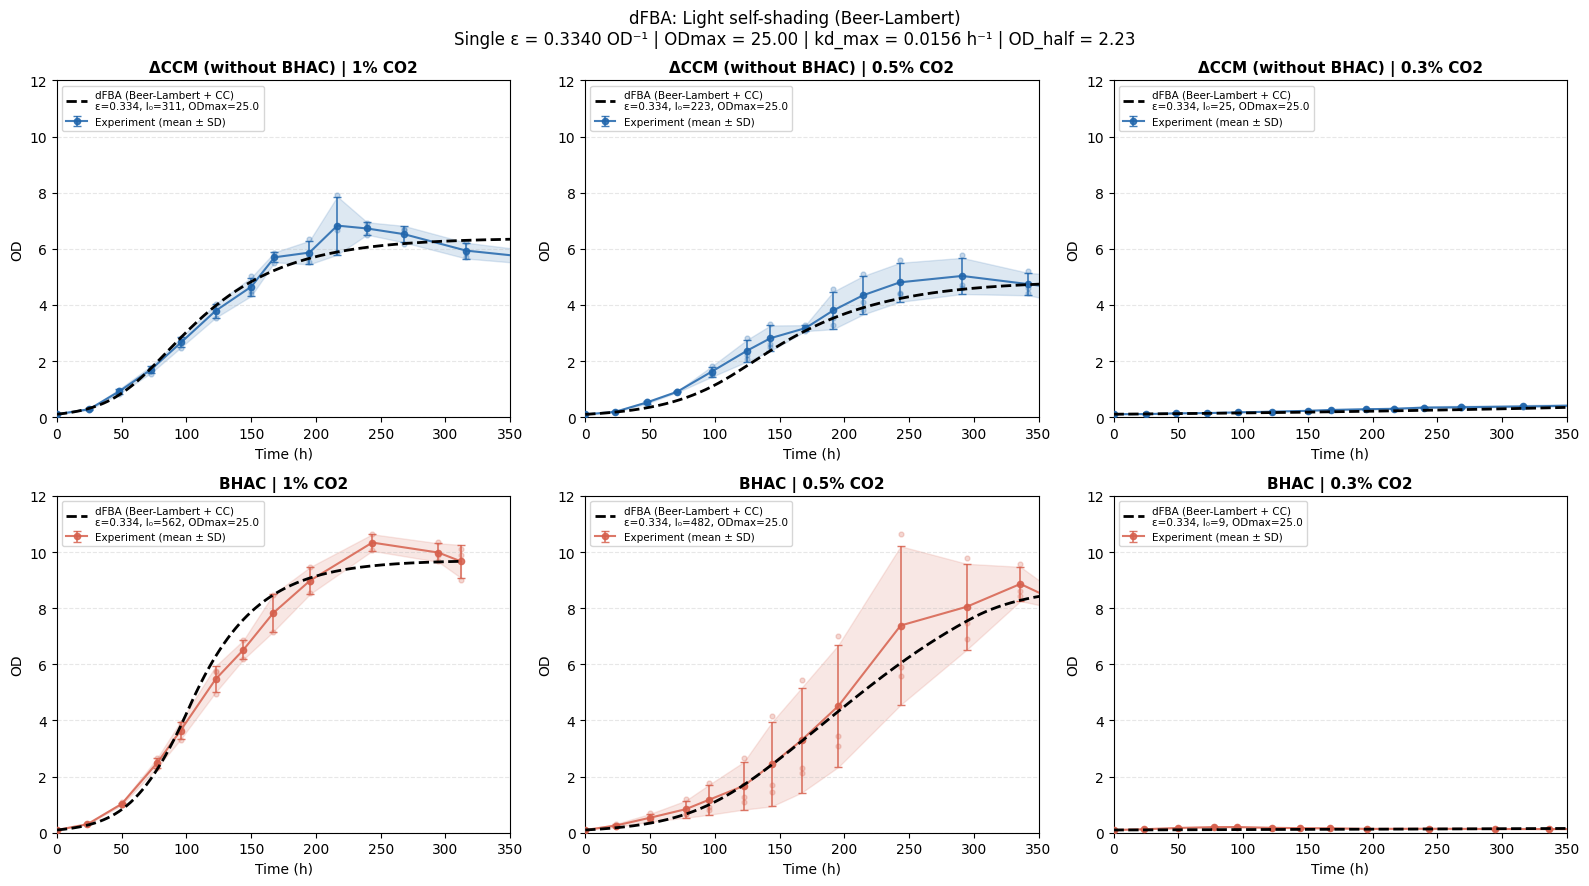

dFBA_Light_self-shading_Beer_Lambert.png


In [11]:
# =============================================================================
# Plot
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row, sk in enumerate(['DCCM', 'BHAC']):
    for col, sheet in enumerate(co2_conditions):
        ax  = axes[row, col]
        df  = data[sheet][sk]
        c   = colors_plot[sk]
        t_exp   = df['time'].values.astype(float)
        od_mean = df['OD_mean'].values.astype(float)
        od_std  = df[['rep1', 'rep2', 'rep3']].std(axis=1).values

        for rep in ['rep1', 'rep2', 'rep3']:
            ax.plot(t_exp, df[rep].values, 'o', color=c, alpha=0.25, ms=3.5)
        ax.fill_between(t_exp, od_mean - od_std, od_mean + od_std,
                        color=c, alpha=0.15)
        ax.errorbar(t_exp, od_mean, yerr=od_std, fmt='o-', color=c,
                    ms=4.5, elinewidth=1.2, capsize=3, alpha=0.85,
                    label='Experiment (mean ± SD)', zorder=3)

        r = light_sim[sheet][sk]
        ax.plot(r['t'], r['OD'], '--', color='black', lw=2,
                label=(f"dFBA (Beer-Lambert + CC)\n"
                       f"ε={eps_fit:.3f}, I₀={I0_fit[(sk, sheet)]:.0f}, "
                       f"ODmax={ODmax_fit:.1f}"),
                zorder=4)
        ax.set_title(f'{strain_labels_plot[sk]} | {sheet}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Time (h)', fontsize=10)
        ax.set_ylabel('OD', fontsize=10)
        ax.set_xlim(0, 350)   # <-- NEW: fixed x-axis range
        ax.set_ylim(0, 12)   # <-- NEW: fixed y-axis range
        ax.legend(fontsize=7.5, loc='upper left')
        ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle(
    'dFBA: Light self-shading (Beer-Lambert)\n'
    f'Single ε = {eps_fit:.4f} OD⁻¹ | ODmax = {ODmax_fit:.2f} | '
    f'kd_max = {kd_max_fit:.4f} h⁻¹ | OD_half = {OD_half_fit:.2f}',
    fontsize=12)
plt.tight_layout()
plt.savefig('dFBA_Light_self-shading_Beer_Lambert.png', dpi=150, bbox_inches='tight')
plt.show()
print('dFBA_Light_self-shading_Beer_Lambert.png')

/Users/reihan/.conda/envs/s_elongatus/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/reihan/.conda/envs/s_elongatus/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


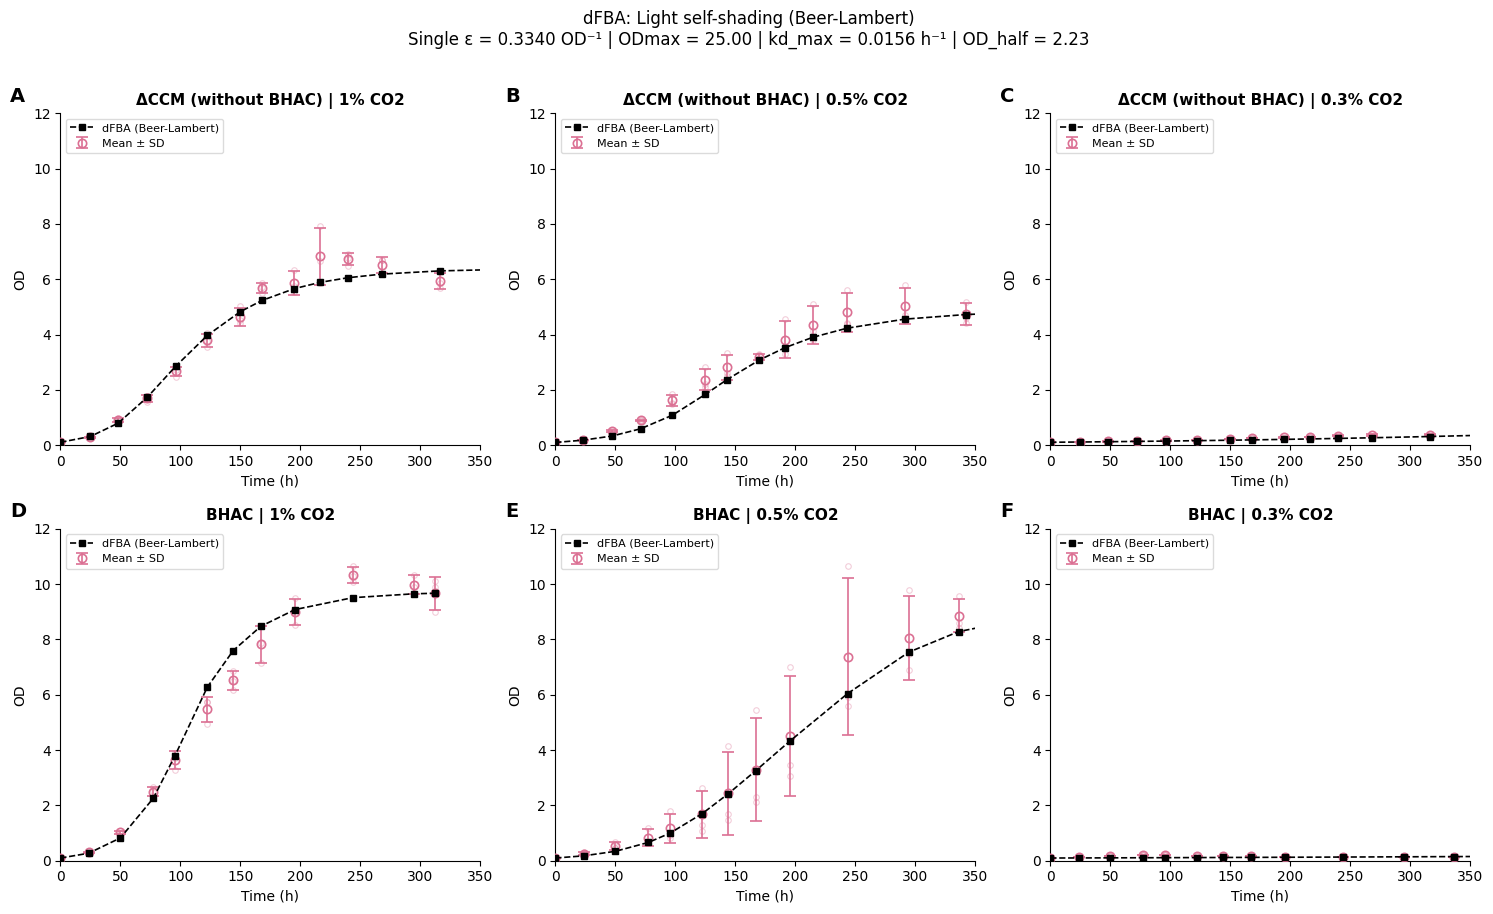

In [12]:
# =============================================================================
# Plot again as errorbar style 
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np
import string

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

panel_labels = list(string.ascii_uppercase)  # ['A', 'B', 'C', 'D', 'E', 'F', ...]
panel_idx = 0

for row, sk in enumerate(['DCCM', 'BHAC']):
    for col, sheet in enumerate(co2_conditions):
        ax = axes[row, col]
        df = light_tables[(sheet, sk)]
        t  = df['time'].values.astype(float)
        reps = df[['rep1', 'rep2', 'rep3']].values.astype(float)
        mean = df['OD_mean'].values.astype(float)
        sd   = np.nanstd(reps, axis=1, ddof=1)

        # Replicates (faint open circles)
        for rep in ['rep1', 'rep2', 'rep3']:
            ax.plot(t, df[rep].values, 'o', color='palevioletred',
                    markersize=4, alpha=0.35, markerfacecolor='none',
                    markeredgewidth=0.8)

        # Mean ± SD errorbar (open circles, no line)
        ax.errorbar(t, mean, yerr=sd,
                    fmt='o', color='palevioletred',
                    markersize=6, markerfacecolor='none', markeredgewidth=1.2,
                    elinewidth=1.2, capsize=4, capthick=1.2,
                    label='Mean ± SD', zorder=3)

        # Simulated OD — solid filled squares
        ax.plot(t, df['OD_sim_light'].values, 's', color='black',
                markersize=5, label='dFBA (Beer-Lambert)', zorder=4,
                linestyle='--', linewidth=1.2)

        ax.set_title(f"{strain_labels_plot[sk]} | {sheet}",
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Time (h)', fontsize=10)
        ax.set_ylabel('OD', fontsize=10)
        ax.set_xlim(0, 350)   # <-- NEW: fixed x-axis range
        ax.set_ylim(0, 12)   # Youanyang wants fixed y-axis range
        ax.legend(fontsize=8, loc='upper left', framealpha=0.7)
        ax.spines[['top', 'right']].set_visible(False)

        # Panel label (A, B, C, ...)
        ax.text(-0.12, 1.08, panel_labels[panel_idx], transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top', ha='left')
        panel_idx += 1

fig.suptitle('dFBA: Light self-shading (Beer-Lambert)\n'
    f'Single ε = {eps_fit:.4f} OD⁻¹ | ODmax = {ODmax_fit:.2f} | '
    f'kd_max = {kd_max_fit:.4f} h⁻¹ | OD_half = {OD_half_fit:.2f}',
    fontsize=12, y=1.01)

plt.tight_layout()
plt.savefig('errorbar_dFBA_Light_self-shading_Beer_Lambert.png', dpi=150, bbox_inches='tight')
plt.savefig('errorbar_dFBA_Light_self-shading_Beer_Lambert.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Cell 12 - Excel table of regenerated data

In [13]:
!pip install xlsxwriter

In [14]:
# =============================================================================
# Export comparison tables to Excel 
# =============================================================================
excel_path = 'dFBA_Light_self_shading_Beer_Lambert.xlsx'
with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    for (sheet, sk), d in light_tables.items():
        sheet_name = f"{sk}_{sheet}"[:31]  # Excel sheet names max 31 chars
        d.to_excel(writer, sheet_name=sheet_name, index=False)
print(f"Saved: {excel_path}")

Saved: dFBA_Light_self_shading_Beer_Lambert.xlsx
